# Phase 2 — Arabic News Preprocessing Notebook




## 1. Import Libraries



In [1]:
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset



In [4]:
DATA_PATH = Path("data2/articles_2026_05.jsonl")

if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/articles_2026_05.jsonl")

df = pd.read_json(DATA_PATH, lines=True)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head(3)

Dataset loaded successfully.
Shape: (16191, 10)


,url,title,body,body_word_count,category,source_credit,tags,date_published,scraped_at,language
0,https://www.aljazeera.net/news/2026/5/1/%d8%a7...,الصحة العالمية تدعو لدخول الأدوية والمستلزمات ...,دعتمنظمة الصحة العالميةإلى السماح بدخول الأدوي...,235,أخبار,المصدر:,"[أخبار, الشرق الأوسط, عربي, فلسطين]",2026-05-01T12:33,2026-05-01 13:04:05.732265+00:00,ar
1,https://www.aljazeera.net/news/2026/5/1/%d8%b1...,رغم مرارة النزوح.. أحلام أطفال السودان تتحدى غ...,لم تحرم الحرب الدائرة فيالسودانالطفلة أفراح من...,668,أخبار,المصدر:,"[أخبار, السودان, الشرق الأوسط, عربي]",2026-05-01T12:32,2026-05-01 13:04:07.146414+00:00,ar
2,https://www.aljazeera.net/news/2026/5/1/%d8%ae...,خان يكشف كواليس ضغوط أمريكية وبريطانية لعرقلة ...,كشف المدعي العام للمحكمةالجنائية الدوليةكريم خ...,256,أخبار,المصدر:,"[أخبار, أوروبا, إسرائيل, الأمريكتان, الشرق الأ...",2026-05-01T12:32,2026-05-01 13:04:08.682343+00:00,ar


## 3. Quick Data Check



In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nMissing values:")
display(df.isna().sum())

print("\nCategory counts:")
display(df["category"].value_counts(dropna=False).to_frame("count"))

Columns:
['url', 'title', 'body', 'body_word_count', 'category', 'source_credit', 'tags', 'date_published', 'scraped_at', 'language']

Missing values:


url                0
title              0
body               0
body_word_count    0
category           0
source_credit      0
tags               0
date_published     0
scraped_at         0
language           0
dtype: int64


Category counts:


,count
category,
أخبار,6462
غير محدد,4964
رياضة,2315
اقتصاد,1277
تقنية,473
ثقافة,255
أسلوب حياة,235
آراء,210


## 4. Simple Visualization



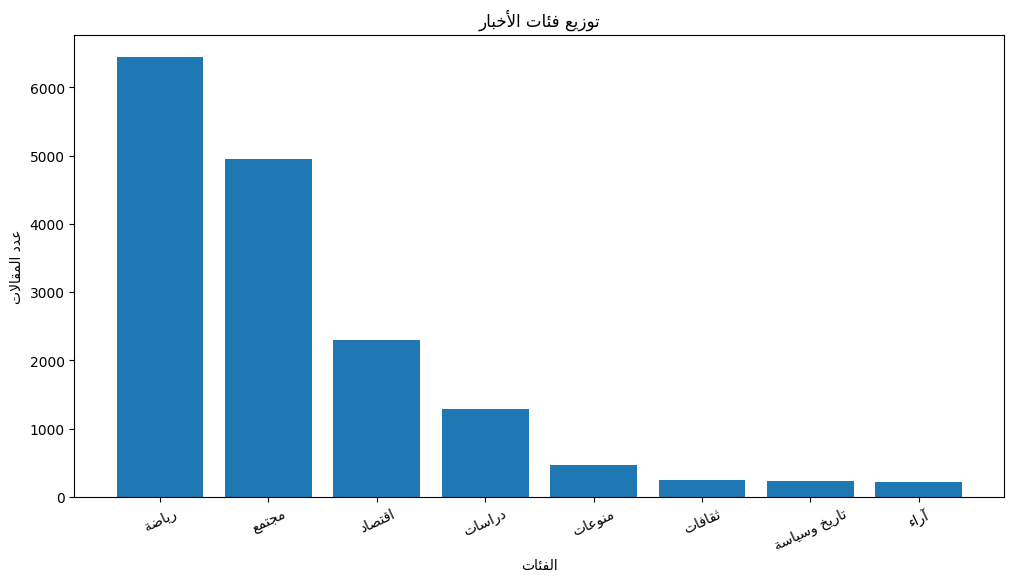

In [6]:
import matplotlib.pyplot as plt
import arabic_reshaper
from bidi.algorithm import get_display

# categories
categories = [
    "رياضة",
    "مجتمع",
    "اقتصاد",
    "دراسات",
    "منوعات",
    "ثقافات",
    "تاريخ وسياسة",
    "آراء"
]

counts = [6450, 4950, 2300, 1280, 470, 250, 230, 210]

# reshape Arabic text
reshaped_categories = [
    get_display(arabic_reshaper.reshape(text))
    for text in categories
]

# plot
plt.figure(figsize=(12,6))

plt.bar(reshaped_categories, counts)

plt.title(get_display(arabic_reshaper.reshape("توزيع فئات الأخبار")))
plt.xlabel(get_display(arabic_reshaper.reshape("الفئات")))
plt.ylabel(get_display(arabic_reshaper.reshape("عدد المقالات")))

plt.xticks(rotation=25)

plt.show()

## 5. Build a Text Column


In [7]:
def safe_text(value):
    # Convert any value to clean string safely.
    if pd.isna(value):
        return ""
    return str(value)

df["raw_text"] = (
    df["title"].apply(safe_text) + " " +
    df["body"].apply(safe_text)
).str.strip()

df[["title", "raw_text"]].head(2)

,title,raw_text
0,الصحة العالمية تدعو لدخول الأدوية والمستلزمات ...,الصحة العالمية تدعو لدخول الأدوية والمستلزمات ...
1,رغم مرارة النزوح.. أحلام أطفال السودان تتحدى غ...,رغم مرارة النزوح.. أحلام أطفال السودان تتحدى غ...


# Semantic Numeric Normalization

To preserve important quantitative information in Arabic news articles,
numeric values are semantically converted into Arabic textual representations.

This helps improve:
- semantic understanding
- contextual retrieval
- embedding quality
- ambiguity-aware matching

Example:
72000 → اثنان وسبعون ألف

In [10]:
from num2words import num2words
import re

def convert_numbers_to_words(text):

    text = str(text)
    numbers = re.findall(r'\d+', text)
    for number in numbers:

        try:

            number_int = int(number)
            # Keep years unchanged
            if 1900 <= number_int <= 2100:
                continue

            # Skip very small numbers
            if number_int < 100:
                continue

            # Convert number to Arabic words
            word = num2words(number_int, lang='ar')

            # Replace number with digit + words
            replacement = f"{number} {word}"

            text = text.replace(number, replacement)

        except:
            pass

    return text

In [11]:
# Apply numeric normalization

df["body"] = df["body"].apply(convert_numbers_to_words)

In [12]:
# ==========================================
# Stable Numeric Semantic Normalization
# ==========================================

from num2words import num2words
import re

def convert_numbers_to_words(text):

    text = str(text)

    # Match integers and decimals
    numbers = re.findall(r'\d+(?:\.\d+)?', text)

    # Prevent partial replacement
    numbers = sorted(numbers, key=len, reverse=True)

    for number in numbers:

        try:

            # Skip years
            if number.isdigit():

                year = int(number)

                if 1900 <= year <= 2100:
                    continue

                text_number = num2words(year, lang='ar')

            else:
                # Handle decimal numbers manually
                integer_part, decimal_part = number.split(".")

                integer_words = num2words(int(integer_part), lang='ar')

                decimal_words = num2words(int(decimal_part), lang='ar')

                text_number = f"{integer_words} فاصلة {decimal_words}"

            # Replace number with words only
            text = text.replace(number, text_number)

        except Exception as e:

            print(f"Error processing {number}: {e}")

    return text


# ==========================================
# SAMPLE TEST
# ==========================================

sample_index = 0

sample_text = df.loc[sample_index, "raw_text"]

converted_text = convert_numbers_to_words(sample_text)

print("========== BEFORE ==========\n")
print(sample_text[:2000])

print("\n\n========== AFTER NUMERIC NORMALIZATION ==========\n")
print(converted_text[:2500])

========== BEFORE ==========

الصحة العالمية تدعو لدخول الأدوية والمستلزمات الأساسية إلى غزة دعتمنظمة الصحة العالميةإلى السماح بدخول الأدوية والمستلزمات الأساسية إلىقطاع غزةالمحاصر دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وجاء ذلك في تدوينة لمدير عام المنظمة تيدروس أدهانوم غيبريسوس على منصة إكس، تعليقا على الأوضاع الإنسانية المتردية في قطاع غزة الذي تفرضإسرائيلعليه حصارا منذ قرابة عقدين وشددته خلال الأعوام الثلاثة الأخيرة. وأوضح غيبريسوس أن المنظمة دعمت إنشاء مركز صحي عائلي جديد في شمالي قطاع غزة، حيث الخدمات الصحية محدودة للغاية، ولا يتمكن جزء كبير من المواطنين من الوصول إليها. وذكر أن المركز يسهم في إيصال الخدمات الصحية مباشرة إلى المواطنين، مؤكدا أن الاحتياجات الصحية في عموم غزة كبيرة جدا. ودعا غيبريسوس إلى السماح بدخول الأدوية والمستلزمات الأساسية إلى القطاع دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وشدد المسؤول الأممي على ضرورة إزالة العوائقالبيروقراطيةالمفروضة على الأدوية الأساسية، ورفع القيود المفروضة على الوصول إلى غزة. وتحاصر إسرائيل قطاع غزة منذ

## 16. AraBERT Word Boundary Splitting

A common scraping artifact in Arabic news is **merged words** — tokens glued together without spaces:

| Merged (broken) | Fixed |
|---|---|
| `دعتمنظمة` | `دعت منظمة` |
| `تفرضاسرائيل` | `تفرض اسرائيل` |
| `اليقطاع` | `الي قطاع` |

We fine-tuned **AraBERT** (`aubmindlab/bert-base-arabertv2`) as a character-level binary classifier:  
*"Should there be a space after this character? → 1 (yes) / 0 (no)"*

Training data was generated **automatically** from our own corpus — no manual labeling needed:
- Clean text → remove spaces → merged text (input)
- Original word boundaries → char labels (target)
- **500K examples** from 15,910 Al Jazeera articles
- **F1 = 0.9827** on held-out test set

In [13]:
import sys
from pathlib import Path

# Add project root so we can import the trained model
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from preprocessing.arabert_word_splitter import WordBoundarySplitter

splitter = WordBoundarySplitter.load()

/home/almadhoun/miniconda3/envs/nlp-project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally to `weight`. Please use a different name to suppress this warning.
A parameter name that contains `beta` will be renamed internally to `bias`. Please use a different name to suppress this warning.
A parameter name that contains `gamma` will be renamed internally 

Loading model from /home/almadhoun/Desktop/second_semester/NLP/nlp_project/models/arabert_splitter …


In [33]:
# Quick demo on known merged examples
demo_cases = [
    "تفرضاسرائيلعليه",
    "منإبادةجماعية",
]

print(f"{'Fixed (output)':<35} {'Merged (input)'}")
print("-" * 70)
for merged in demo_cases:
    fixed = splitter.fix(merged)
    print(f"{merged:<35}  {fixed}")

Fixed (output)                      Merged (input)
----------------------------------------------------------------------
تفرضاسرائيلعليه                      تفرض اسرائيل عليه
منإبادةجماعية                        من إبادة جماعية


In [15]:
# Before / After on a real article body
sample = df.loc[0, "body"]

print("BEFORE (first 300 chars):")
print(sample[:300])
print()
print("AFTER  (first 300 chars):")
print(splitter.fix(sample)[:300])

BEFORE (first 300 chars):
دعتمنظمة الصحة العالميةإلى السماح بدخول الأدوية والمستلزمات الأساسية إلىقطاع غزةالمحاصر دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وجاء ذلك في تدوينة لمدير عام المنظمة تيدروس أدهانوم غيبريسوس على منصة إكس، تعليقا على الأوضاع الإنسانية المتردية في قطاع غزة الذي تفرضإسرائيلعليه حصارا منذ

AFTER  (first 300 chars):
دعت منظمة الصحة الع المية إلى السماح بدخول الأدوية والمستل زمات الأساسية إلىقطاع غزةالم حاصر دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وجاء ذلك في تدوينة لمدير عام المنظمة تيدروس أدهانوم غيب ريسوس على منصة إكس، تعليقا على الأوضاع الإنسانية المتردية في قطاع غزة الذي تفرض إسرائيل عليه ح


## 6. Arabic Normalization Rules

مثال:
- `أ، إ، آ` ⟵ `ا`
- `ى` ⟵ `ي`
- إزالة التشكيل والتطويل

In [21]:

ARABIC_DIACRITICS = re.compile(r"[\u0617-\u061A\u064B-\u0652]")
TATWEEL = "ـ"
NON_ARABIC = re.compile(r"[^ء-ي\s]")
EXTRA_SPACES = re.compile(r"\s+")

def normalize_arabic(text):
    # Normalize Arabic text in a simple and clear way.
    text = safe_text(text)

    text = ARABIC_DIACRITICS.sub("", text)
    text = text.replace(TATWEEL, "")

    text = re.sub("[إأآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ة", "ه")

    text = NON_ARABIC.sub(" ", text)
    text = EXTRA_SPACES.sub(" ", text).strip()

    return text

## 7. Tokenization

 **simple regex tokenization** 




In [22]:
def tokenize_arabic(text):
    # Tokenize Arabic text after normalization.
    normalized = normalize_arabic(text)
    tokens = normalized.split()
    return tokens

def remove_stopwords(tokens, min_len=2):
    # Remove custom stopwords and very short tokens.
    filtered_tokens = [
        token for token in tokens
        if token not in CUSTOM_STOPWORDS and len(token) > min_len
    ]
    return filtered_tokens

def preprocess_text(text):
    # Full preprocessing pipeline for one Arabic text.
    normalized = normalize_arabic(text)
    tokens = tokenize_arabic(normalized)
    filtered_tokens = remove_stopwords(tokens)
    processed_text = " ".join(filtered_tokens)

    return {
        "normalized_text": normalized,
        "tokens": tokens,
        "filtered_tokens": filtered_tokens,
        "processed_text": processed_text
    }

## 8. Custom Arabic Stopwords


بدل `NLTK`، بنستخدم قائمة مخصصة للأخبار العربية تشمل:
- حروف الجر
- حروف العطف
- أدوات الشرط
- أدوات النفي
- ظروف الزمان والمكان
- ضمائر 
- كلمات عامة في الأخبار لا تضيف معنى قوي



In [23]:
PREPOSITIONS = {
    "من", "الي", "الى", "عن", "علي", "على", "في", "ب", "ل", "ك",
    "بين", "خلال", "حول", "تحت", "فوق", "داخل", "خارج", "امام", "خلف",
    "ضد", "نحو", "عبر", "لدي", "لدى", "عند", "مع", "منذ", "حتى"
}

CONJUNCTIONS = {
    "و", "ف", "ثم", "او", "ام", "بل", "لكن", "لكنها", "لكنهم",
    "كما", "كذلك", "ايضا", "بينما", "حيث", "اذ", "اذا", "ان", "انما"
}

TIME_WORDS = {
    "اليوم", "امس", "غدا", "صباحا", "مساء", "ليلا", "نهارا",
    "الان", "لاحقا", "سابقا", "اخيرا", "مؤخرا", "حاليا",
    "قبل", "بعد", "اثناء", "حين", "عندما", "وقت", "لحظه",
    "السبت", "الاحد", "الاثنين", "الثلاثاء", "الاربعاء", "الخميس", "الجمعه",
    "يناير", "فبراير", "مارس", "ابريل", "مايو", "يونيو",
    "يوليو", "اغسطس", "سبتمبر", "اكتوبر", "نوفمبر", "ديسمبر"
}

PLACE_WORDS = {
    "هنا", "هناك", "هنالك", "اين", "اي", "كل", "بعض", "جميع",
    "وسط", "شمال", "جنوب", "شرق", "غرب", "شرقي", "غربي", "شمالي", "جنوبي"
}

PRONOUNS = {
    "انا", "انت", "انتم", "انتن", "هو", "هي", "هم", "هن", "نحن",
    "هذا", "هذه", "هؤلاء", "ذلك", "تلك",
    "الذي", "التي", "الذين", "اللذان", "اللتان", "ما", "من"
}

NEGATION_AND_PARTICLES = {
    "لا", "لم", "لن", "ليس", "ليست", "غير", "دون", "قد", "لقد",
    "هل", "الا", "اما", "ان", "انها", "انه", "بان", "بانها", "بانه",
    "كان", "كانت", "كانوا", "يكون", "تكون", "يعد", "تعد"
}

NEWS_FILLER_WORDS = {
    "قال", "قالت", "ذكر", "ذكرت", "اضاف", "اضافت", "اوضح", "اوضحت",
    "اشار", "اشارت", "اكد", "اكدت", "اعلن", "اعلنت", "بحسب", "وفق",
    "جاء", "جاءت", "تابع", "تابعت", "صرح", "صرحت", "بين", "بينت",
    "افاد", "افادت", "نقل", "نقلت", "حسب", "وكاله", "مصادر", "مصدر",
    "تصريح", "بيان", "تقرير", "تقارير", "صحيفه", "قناه", "موقع"
}

CUSTOM_STOPWORDS = (
    PREPOSITIONS |
    CONJUNCTIONS |
    TIME_WORDS |
    PLACE_WORDS |
    PRONOUNS |
    NEGATION_AND_PARTICLES |
    NEWS_FILLER_WORDS
)

print("Number of custom stopwords:", len(CUSTOM_STOPWORDS))
print(sorted(list(CUSTOM_STOPWORDS))[:80])


Number of custom stopwords: 184
['ابريل', 'اثناء', 'اخيرا', 'اذ', 'اذا', 'اشار', 'اشارت', 'اضاف', 'اضافت', 'اعلن', 'اعلنت', 'اغسطس', 'افاد', 'افادت', 'اكتوبر', 'اكد', 'اكدت', 'الا', 'الاثنين', 'الاحد', 'الاربعاء', 'الان', 'التي', 'الثلاثاء', 'الجمعه', 'الخميس', 'الذي', 'الذين', 'السبت', 'اللتان', 'اللذان', 'الى', 'الي', 'اليوم', 'ام', 'اما', 'امام', 'امس', 'ان', 'انا', 'انت', 'انتم', 'انتن', 'انما', 'انه', 'انها', 'او', 'اوضح', 'اوضحت', 'اي', 'ايضا', 'اين', 'ب', 'بان', 'بانه', 'بانها', 'بحسب', 'بعد', 'بعض', 'بل', 'بيان', 'بين', 'بينت', 'بينما', 'تابع', 'تابعت', 'تحت', 'تصريح', 'تعد', 'تقارير', 'تقرير', 'تكون', 'تلك', 'ثم', 'جاء', 'جاءت', 'جميع', 'جنوب', 'جنوبي', 'حاليا']


## 8.  Arabic Lemmatization

with MorphologyDB & Analyzer from camel_tools

In [24]:
from camel_tools.morphology.database import MorphologyDB
from camel_tools.morphology.analyzer import Analyzer

# Load morphology database
db = MorphologyDB.builtin_db()

# Create analyzer
analyzer = Analyzer(db)

def lemmatize_word(word):

    analyses = analyzer.analyze(word)

    if analyses:
        return analyses[0]['lex']
    
    return word

# Example
words = ["الشهداء", "المهاجمون", "الفلسطينيين"]

lemmas = [lemmatize_word(word) for word in words]

print(lemmas)

['شَهِيد', 'مُهاجِم', 'فِلَسْطِينِيّ']


## 9. Test on One Article



In [25]:
sample_index = 0
sample_text = df.loc[sample_index, "raw_text"]

numeric_text = convert_numbers_to_words(sample_text)

result = preprocess_text(sample_text)

print("========== BEFORE ==========")
print(sample_text[:1000])

print("\n========== AFTER NUMERIC NORMALIZATION ==========")
print(numeric_text[:1100])

print("\n========== NORMALIZED ==========")
print(result["normalized_text"][:1000])

print("\n========== AFTER STOPWORD REMOVAL ==========")
print(result["processed_text"][:1000])

print("\nFirst 40 filtered tokens:")
print(result["filtered_tokens"][:1000])

========== BEFORE ==========
الصحة العالمية تدعو لدخول الأدوية والمستلزمات الأساسية إلى غزة دعتمنظمة الصحة العالميةإلى السماح بدخول الأدوية والمستلزمات الأساسية إلىقطاع غزةالمحاصر دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وجاء ذلك في تدوينة لمدير عام المنظمة تيدروس أدهانوم غيبريسوس على منصة إكس، تعليقا على الأوضاع الإنسانية المتردية في قطاع غزة الذي تفرضإسرائيلعليه حصارا منذ قرابة عقدين وشددته خلال الأعوام الثلاثة الأخيرة. وأوضح غيبريسوس أن المنظمة دعمت إنشاء مركز صحي عائلي جديد في شمالي قطاع غزة، حيث الخدمات الصحية محدودة للغاية، ولا يتمكن جزء كبير من المواطنين من الوصول إليها. وذكر أن المركز يسهم في إيصال الخدمات الصحية مباشرة إلى المواطنين، مؤكدا أن الاحتياجات الصحية في عموم غزة كبيرة جدا. ودعا غيبريسوس إلى السماح بدخول الأدوية والمستلزمات الأساسية إلى القطاع دون تأخير، لبدء إعادة بناء الخدمات الصحية على نطاق واسع. وشدد المسؤول الأممي على ضرورة إزالة العوائقالبيروقراطيةالمفروضة على الأدوية الأساسية، ورفع القيود المفروضة على الوصول إلى غزة. وتحاصر إسرائيل قطاع غزة منذ 

## 10. Apply Preprocessing to All Articles

new cols added to the data:
- `normalized_text`
- `tokens`
- `filtered_tokens`
- `processed_text`



In [26]:
processed_records = df["raw_text"].apply(preprocess_text)

df["normalized_text"] = processed_records.apply(lambda x: x["normalized_text"])
df["tokens"] = processed_records.apply(lambda x: x["tokens"])
df["filtered_tokens"] = processed_records.apply(lambda x: x["filtered_tokens"])
df["processed_text"] = processed_records.apply(lambda x: x["processed_text"])

df[["title", "processed_text"]].head(3)

,title,processed_text
0,الصحة العالمية تدعو لدخول الأدوية والمستلزمات ...,الصحه العالميه تدعو لدخول الادويه والمستلزمات ...
1,رغم مرارة النزوح.. أحلام أطفال السودان تتحدى غ...,رغم مراره النزوح احلام اطفال السودان تتحدي غيا...
2,خان يكشف كواليس ضغوط أمريكية وبريطانية لعرقلة ...,خان يكشف كواليس ضغوط امريكيه وبريطانيه لعرقله ...


## 11. Preprocessing Quality Check


,word,count
0,ايران,22320
1,الحرب,19911
2,وفي,16624
3,الامريكيه,14092
4,اكثر,13318
5,المتحده,13035
6,ترمب,12612
7,وهو,12434
8,عام,11652
9,مما,10720


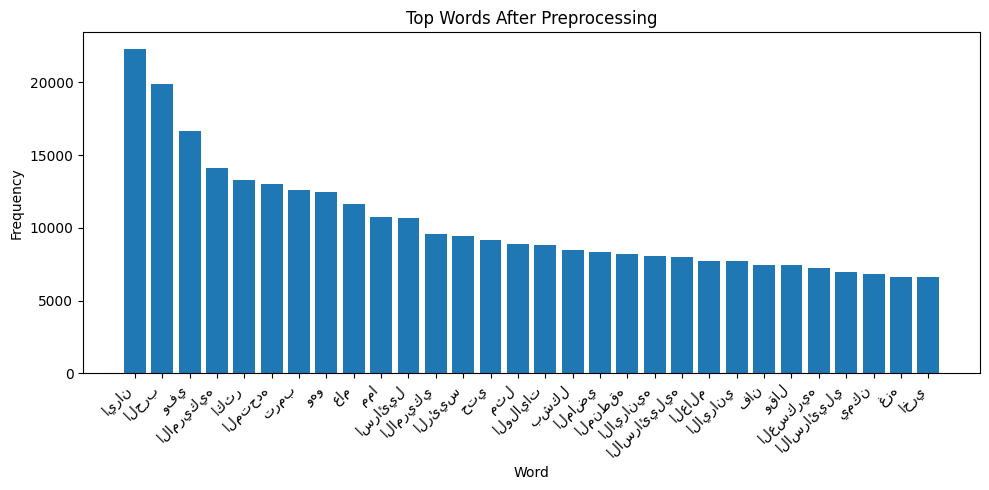

In [27]:
all_filtered_tokens = []
for tokens in df["filtered_tokens"]:
    all_filtered_tokens.extend(tokens)

top_words = Counter(all_filtered_tokens).most_common(30)
top_words_df = pd.DataFrame(top_words, columns=["word", "count"])

display(top_words_df)

plt.figure(figsize=(10, 5))
plt.bar(top_words_df["word"], top_words_df["count"])
plt.title("Top Words After Preprocessing")
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 12. Ambiguity-Friendly Preprocessing Check
making sure that no important words are removed because our project focuses on **Ambiguity Resolution**
- أسماء الأماكن: `غزه، رفح، خان، يونس، جباليا`
- الأحداث: `حرب، قصف، غاره، شهداء، نزوح`
- الجهات: `اسرائيل، الاحتلال، الجيش`



In [28]:
important_terms = [
    "غزه", "رفح", "خان", "يونس", "جباليا", "دير", "البلح",
    "حرب", "قصف", "غاره", "شهداء", "نزوح", "احتلال", "اسرائيل", "الجيش"
]

existing_terms = {}
for term in important_terms:
    count = sum(tokens.count(term) for tokens in df["filtered_tokens"])
    existing_terms[term] = count

important_terms_df = pd.DataFrame(
    existing_terms.items(),
    columns=["important_term", "count_after_preprocessing"]
).sort_values("count_after_preprocessing", ascending=False)

display(important_terms_df)

,important_term,count_after_preprocessing
13,اسرائيل,10713
0,غزه,6658
14,الجيش,4758
7,حرب,4728
8,قصف,1027
1,رفح,520
9,غاره,484
2,خان,351
3,يونس,347
11,نزوح,346


## 13. Mini Ambiguity Lexicon

a list to help us lately in **Query Expansion**.
ex:
if query was `حرب غزة`, it may be related to `قصف، غارة، شهداء، رفح، خان يونس`

In [29]:
AMBIGUITY_LEXICON = {
    "حرب غزه": [
        "غزه", "قطاع", "رفح", "خان يونس", "جباليا", "دير البلح",
        "قصف", "غاره", "استهداف", "شهداء", "جرحي", "نزوح",
        "وقف اطلاق النار", "خروقات", "حصار"
    ],
    "اسرائيل": [
        "اسرائيل", "الاحتلال", "الجيش الاسرائيلي", "تل ابيب"
    ],
    "هدنه": [
        "وقف اطلاق النار", "خروقات", "تصعيد", "قصف", "اتفاق"
    ],
    "ضحايا": [
        "شهداء", "قتلي", "مصابون", "جرحي", "ضحايا"
    ]
}

AMBIGUITY_LEXICON

{'حرب غزه': ['غزه',
  'قطاع',
  'رفح',
  'خان يونس',
  'جباليا',
  'دير البلح',
  'قصف',
  'غاره',
  'استهداف',
  'شهداء',
  'جرحي',
  'نزوح',
  'وقف اطلاق النار',
  'خروقات',
  'حصار'],
 'اسرائيل': ['اسرائيل', 'الاحتلال', 'الجيش الاسرائيلي', 'تل ابيب'],
 'هدنه': ['وقف اطلاق النار', 'خروقات', 'تصعيد', 'قصف', 'اتفاق'],
 'ضحايا': ['شهداء', 'قتلي', 'مصابون', 'جرحي', 'ضحايا']}

## 14. Simple Query Preprocessing

preparing the query in the same way as the articles, so that a fair comparison can be made between them later in the **Semantic Search**.

In [30]:
def preprocess_query(query):
    # Preprocess user query using the same text pipeline.
    return preprocess_text(query)["processed_text"]

test_queries = [
    "حرب غزة",
    "قصف في القطاع",
    "خروقات الهدنة",
    "الإحتلال الإسرائيلي"
]

for q in test_queries:
    print(f"Original Query: {q}")
    print(f"Processed Query: {preprocess_query(q)}")
    print("-" * 50)

Original Query: حرب غزة
Processed Query: حرب غزه
--------------------------------------------------
Original Query: قصف في القطاع
Processed Query: قصف القطاع
--------------------------------------------------
Original Query: خروقات الهدنة
Processed Query: خروقات الهدنه
--------------------------------------------------
Original Query: الإحتلال الإسرائيلي
Processed Query: الاحتلال الاسرائيلي
--------------------------------------------------


## 15. Save Preprocessed Dataset

- `preprocessed_articles.csv`
- `preprocessed_articles.jsonl`

In [ ]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

columns_to_save = [
    "url", "title", "body", "category", "tags", "date_published",
    "raw_text", "normalized_text", "processed_text"
]

available_columns = [col for col in columns_to_save if col in df.columns]

csv_path = OUTPUT_DIR / "preprocessed_articles.csv"
jsonl_path = OUTPUT_DIR / "preprocessed_articles.jsonl"

df[available_columns].to_csv(csv_path, index=False, encoding="utf-8-sig")
df[available_columns].to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

print("Saved successfully:")
print(csv_path)
print(jsonl_path)

## 16. Final Summary

what we made in this notebook:
1. loading data
2. quick test for nulls
3. creating a new col that combine title + body 
4. cleaning text
5. using **custom Arabic stopwords** instead of `NLTK`.
6. preparing `processed_text` for **Semantic Search** & **Ambiguity Resolution**.
7. making sure that the important words not deleted
8. saving clean copy to the next phase

next step:
**Embedding + Semantic Retrieval + Ambiguity-aware Query Expansion**

In [ ]:
from num2words import num2words

number = 235.57

text_number = num2words(number, lang='ar')

print(text_number)